In [1]:
# Подключение Python к базе, импорт необходимых библиотек

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

conn = sqlite3.connect(r'C:\Users\anast\OneDrive\Desktop\project\bike_project')

orders = pd.read_sql('SELECT * FROM orders', conn)
order_items = pd.read_sql('SELECT * FROM order_items', conn)
products = pd.read_sql('SELECT * FROM products', conn)
stores = pd.read_sql('SELECT * FROM stores', conn)
categories = pd.read_sql('SELECT * FROM categories', conn)

order_items['revenue'] = order_items['quantity'] * order_items['list_price'] * (1 - order_items['discount'])
order_revenue = order_items.groupby('order_id')['revenue'].sum().reset_index()
orders = orders.merge(order_revenue, on='order_id', how='left')
orders['order_date'] = pd.to_datetime(orders['order_date'])

status_map = {1: 'Pending', 2: 'Processing', 3: 'Rejected', 4: 'Completed'}
orders['status_name'] = orders['order_status'].map(status_map)

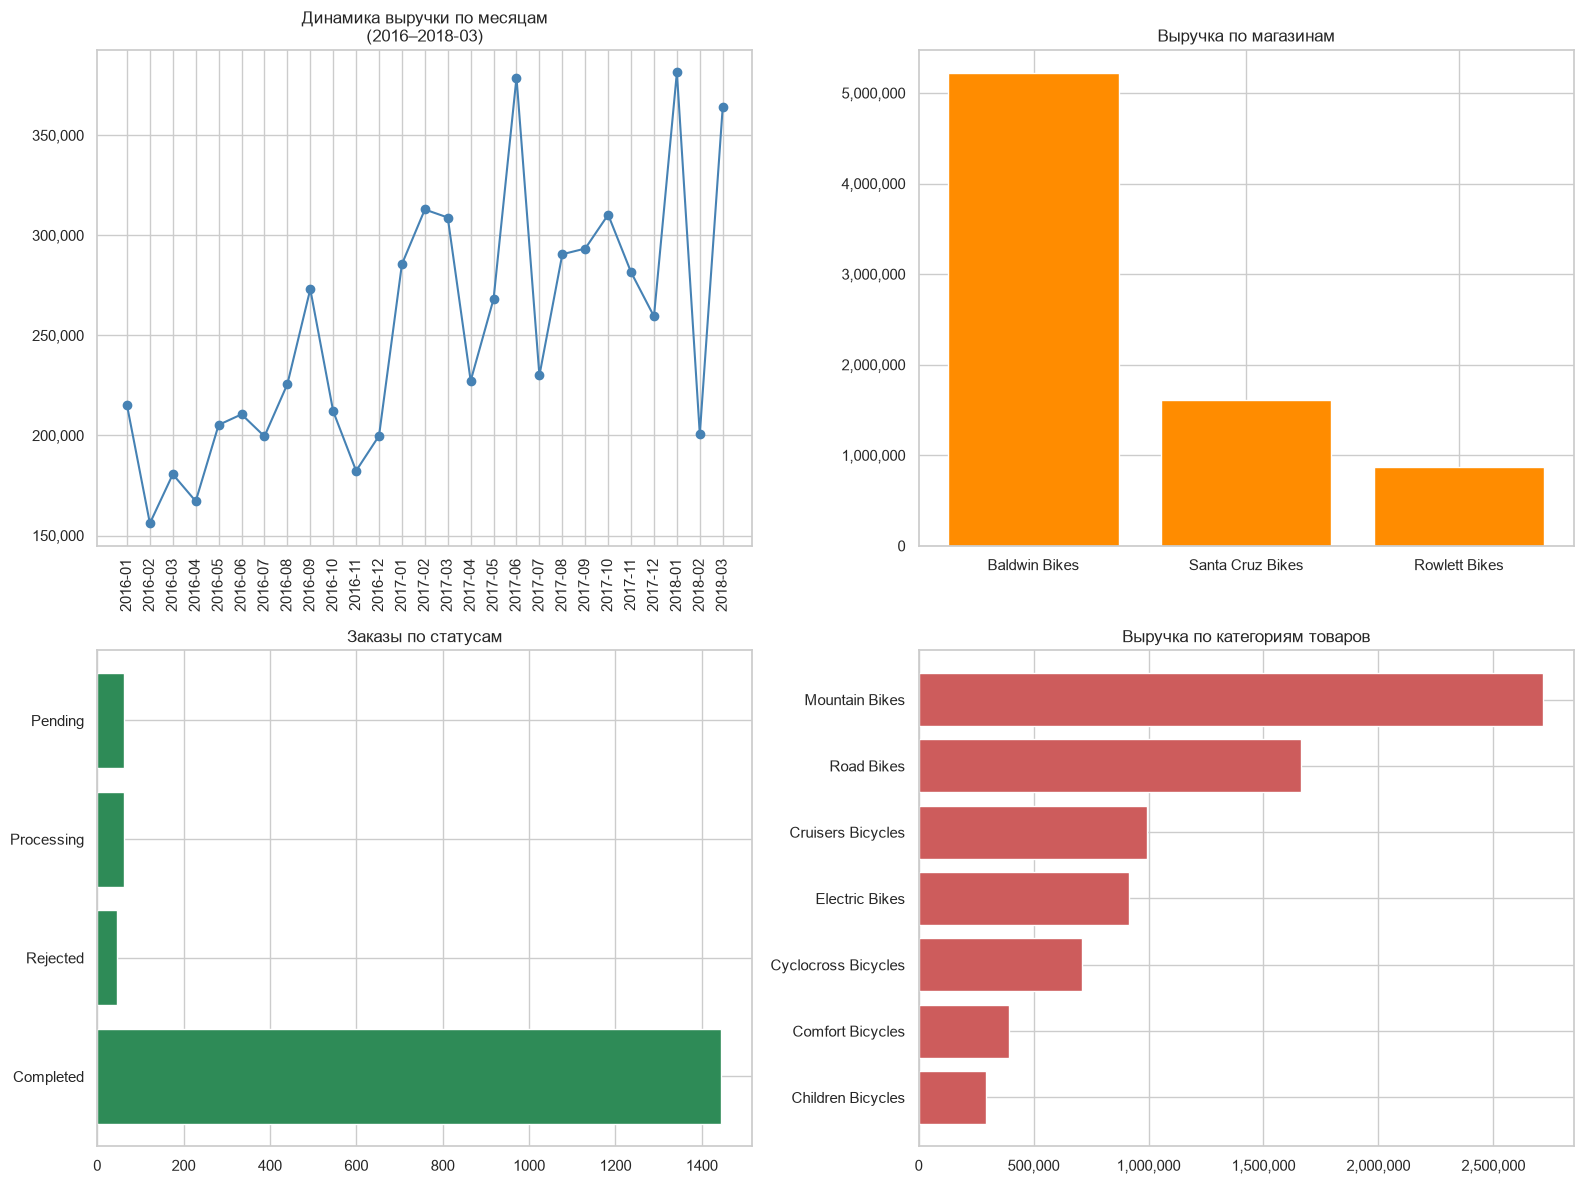

In [2]:
# Визуализация

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: динамика выручки по месяцам (без аномального "хвоста" после марта 2018)

orders_clean = orders[orders['order_date'] <= '2018-03-31'].copy()
orders_clean['month'] = orders_clean['order_date'].dt.to_period('M').astype(str)
monthly_revenue = orders_clean.groupby('month')['revenue'].sum()

axes[0, 0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='steelblue')
axes[0, 0].set_title('Динамика выручки по месяцам\n(2016–2018-03)')
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# График 2: выручка по отдельным магазинам

rev_by_store = (
    orders.merge(stores[['store_id', 'store_name']], on='store_id')
    .groupby('store_name')['revenue'].sum()
    .sort_values(ascending=False)
)
axes[0, 1].bar(rev_by_store.index, rev_by_store.values, color='darkorange')
axes[0, 1].set_title('Выручка по магазинам')
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# График 3: воронка заказов по статусам

funnel_counts = orders['status_name'].value_counts().reindex(['Pending', 'Processing', 'Rejected', 'Completed'])
axes[1, 0].barh(funnel_counts.index, funnel_counts.values, color='seagreen')
axes[1, 0].set_title('Заказы по статусам')
axes[1, 0].invert_yaxis()

# График 4: топ категорий по выручке

items_full = order_items.merge(products, on='product_id').merge(categories, on='category_id')
rev_by_category = items_full.groupby('category_name')['revenue'].sum().sort_values(ascending=True)
axes[1, 1].barh(rev_by_category.index, rev_by_category.values, color='indianred')
axes[1, 1].set_title('Выручка по категориям товаров')
axes[1, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('dashboard_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Сводная таблица с ключевыми показателями

total_revenue = orders['revenue'].sum()
aov = orders['revenue'].mean()
total_orders = len(orders)
completion_rate = (orders['status_name'] == 'Completed').mean() * 100
rejection_rate = (orders['status_name'] == 'Rejected').mean() * 100

summary = pd.DataFrame({
    'Метрика': [
        'Общая выручка', 'Средний чек (AOV)', 'Всего заказов',
        'Completion rate', 'Rejection rate'
    ],
    'Значение': [
        f'${total_revenue:,.0f}', f'${aov:,.2f}', f'{total_orders:,}',
        f'{completion_rate:.1f}%', f'{rejection_rate:.1f}%'
    ]
})

print(summary.to_string(index=False))

          Метрика   Значение
    Общая выручка $7,689,117
Средний чек (AOV)  $4,761.06
    Всего заказов      1,615
  Completion rate      89.5%
   Rejection rate       2.8%
